## Lab Measurements

In [ ]:
import pandas            as pd
import miceforest        as mf
import matplotlib.pyplot as plt
import numpy             as np
import os
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
os.chdir(r'T:\lab_research\RES-Folder-UPOD\ODIN-UC4\E_ResearchData\2_ResearchData\20240805')

In [ ]:
df_lab = pd.read_parquet('lab_20240805.parquet')

In [ ]:
df_lab.studyId_0831 = df_lab.studyId_0831.astype(int) # Converto to int to have more clear view

In [74]:
df_lab.columns # How many of those are relevant to us?

Index(['studyId_0831', 'identifier_value', 'basedOn_ProcedureRequest_value',
       'LabID', 'category3_display_original', 'category4_code_original',
       'code_code_original', 'code_display_original', 'code2_code_original',
       'code2_display_original', 'code3_display_original',
       'code3_system_original', 'code4_display_original', 'comment',
       'effectiveDateTime', 'interpretation_display', 'referenceRange_text',
       'status_display_original', 'valueQuantity_code_original',
       'valueQuantity_comparator', 'valueQuantity_unit',
       'valueQuantity_unit_original', 'valueQuantity_value', 'valueString',
       'Practitioner_Rol', 'gender', 'organization_Organization_value',
       'specialty_specialtyAGB_display', 'index_date'],
      dtype='object')

In [79]:
units = df_lab.groupby('code_display_original').last().valueQuantity_code_original.to_list()

Let's remove uneuseful columns

In [73]:
df_lab.valueString

0         None
1         None
2         None
3         None
4         None
          ... 
139585    None
139586    None
139587    None
139588    None
139589     >90
Name: valueString, Length: 139590, dtype: object

In [ ]:
df_lab = df_lab.drop(['identifier_value', 'basedOn_ProcedureRequest_value',
                      'LabID', 'category3_display_original', 'category4_code_original',
                      'code_code_original','code2_code_original',
                      'code2_display_original', 'code3_display_original',
                      'interpretation_display',
                      'code3_system_original', 'code4_display_original', 'comment',
                      'status_display_original',
                      'valueQuantity_comparator', 'valueQuantity_unit',
                      'valueQuantity_unit_original', 'valueString',
                      'Practitioner_Rol', 'gender', 'organization_Organization_value',
                      'specialty_specialtyAGB_display', 'index_date'],axis='columns')

In [ ]:
df_lab.query('code_display_original == "CRP"')

Storing the reference range of values per substance

In [ ]:
substances = pd.read_parquet('substances_range.parquet')
substances

In [ ]:
substances.loc['CRP']['rMin'] = 0.5

Pivoting on the chemical sub

In [ ]:
df_lab_pivoted = df_lab.pivot(columns='code_display_original', values='valueQuantity_value')
df_lab_pivoted

Adding useful columns

In [ ]:
df_lab_pivoted.insert(0, 'studyId_0831', df_lab.studyId_0831.values,allow_duplicates=True)
df_lab_pivoted['effectiveDateTime'] =  df_lab.effectiveDateTime

In [ ]:
df_lab_pivoted.columns

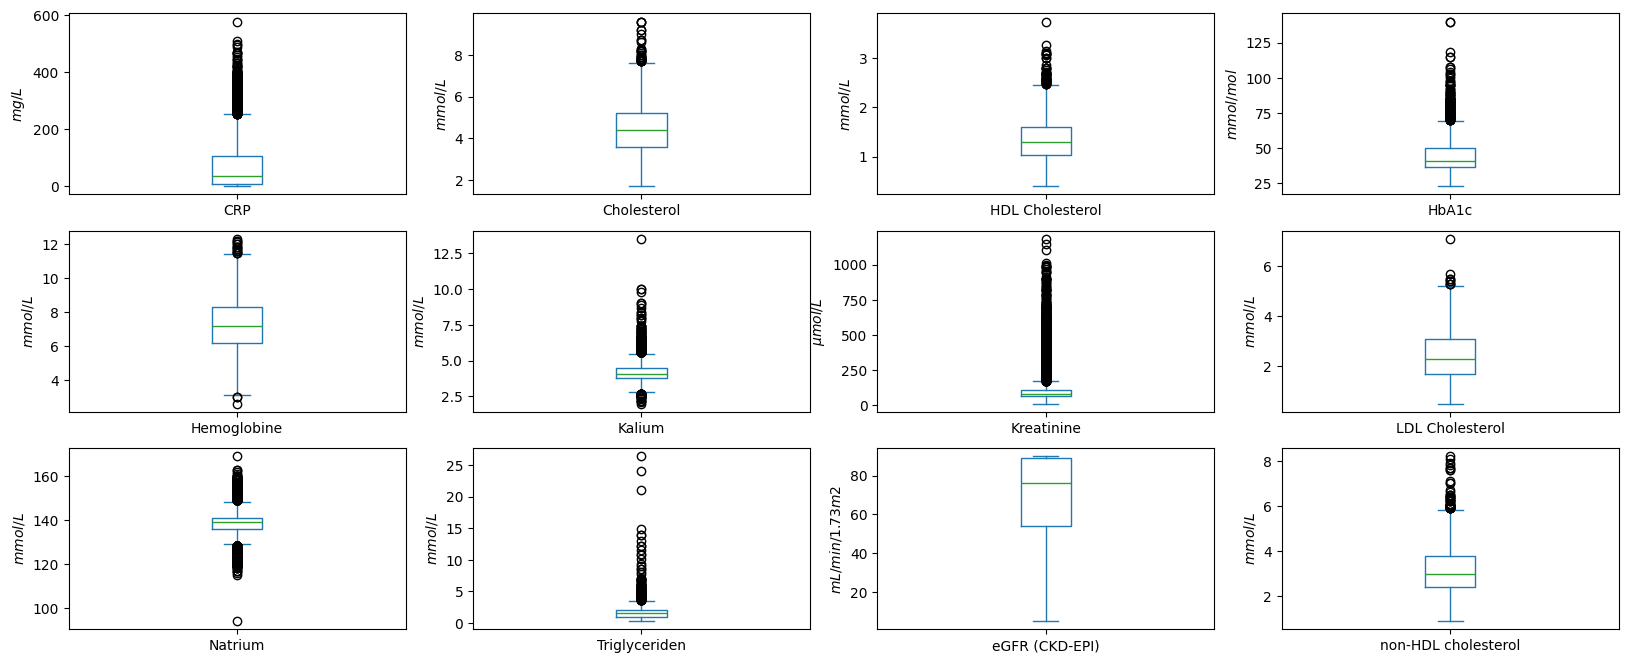

In [87]:
ax = df_lab_pivoted[['CRP', 'Cholesterol', 'HDL Cholesterol', 'HbA1c',
       'Hemoglobine', 'Kalium', 'Kreatinine', 'LDL Cholesterol', 'Natrium',
       'Triglyceriden', 'eGFR (CKD-EPI)', 'non-HDL cholesterol',]]\
              .plot(kind='box',
                    subplots=True,
                    layout=[3,4],
                    figsize=[20,10],
                    )

for a,l in zip(ax,units):
    a.set_ylabel(r'${}$'.format(l))



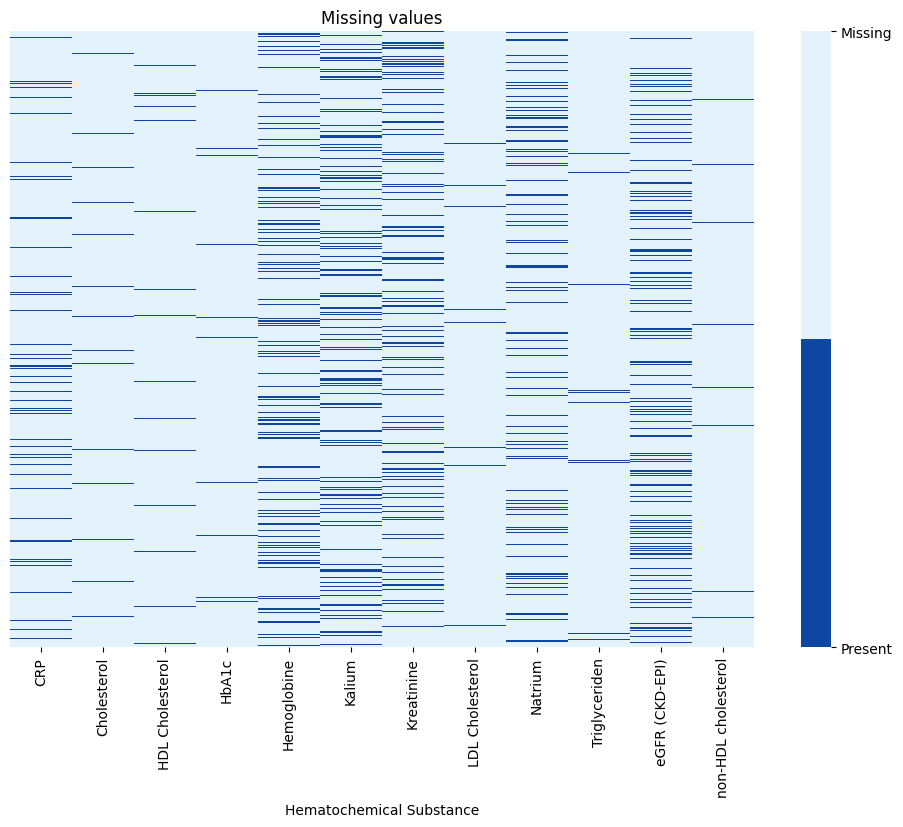

In [71]:

myColors = ('#0D47A1', '#E3F2FD')
cmap = LinearSegmentedColormap.from_list('Custom', myColors, len(myColors))
fig = plt.figure(figsize=[12,8])

ax = fig.add_axes(
    sns.heatmap(df_lab_pivoted[['CRP', 'Cholesterol', 'HDL Cholesterol', 'HbA1c',
                                'Hemoglobine', 'Kalium', 'Kreatinine', 'LDL Cholesterol', 'Natrium',
                                'Triglyceriden', 'eGFR (CKD-EPI)', 'non-HDL cholesterol',
                                ]].isna(),
                 yticklabels='', 
                 cmap=cmap,
                 ))

ax.set_xlabel('Hematochemical Substance')
ax.set_title('Missing values')
cb = ax.collections[0].colorbar
cb.set_ticks([0,1])
cb.set_ticklabels(['Present','Missing'])

## Patient Level exploration

---

Group by patients, convert to list to have the complete timeseries

In [ ]:
df_lab_timeseries = df_lab_pivoted.groupby('studyId_0831').agg(lambda x: x.to_list()).reset_index()
df_lab_timeseries

Text(0, 0.5, 'HDL Cholesterol')

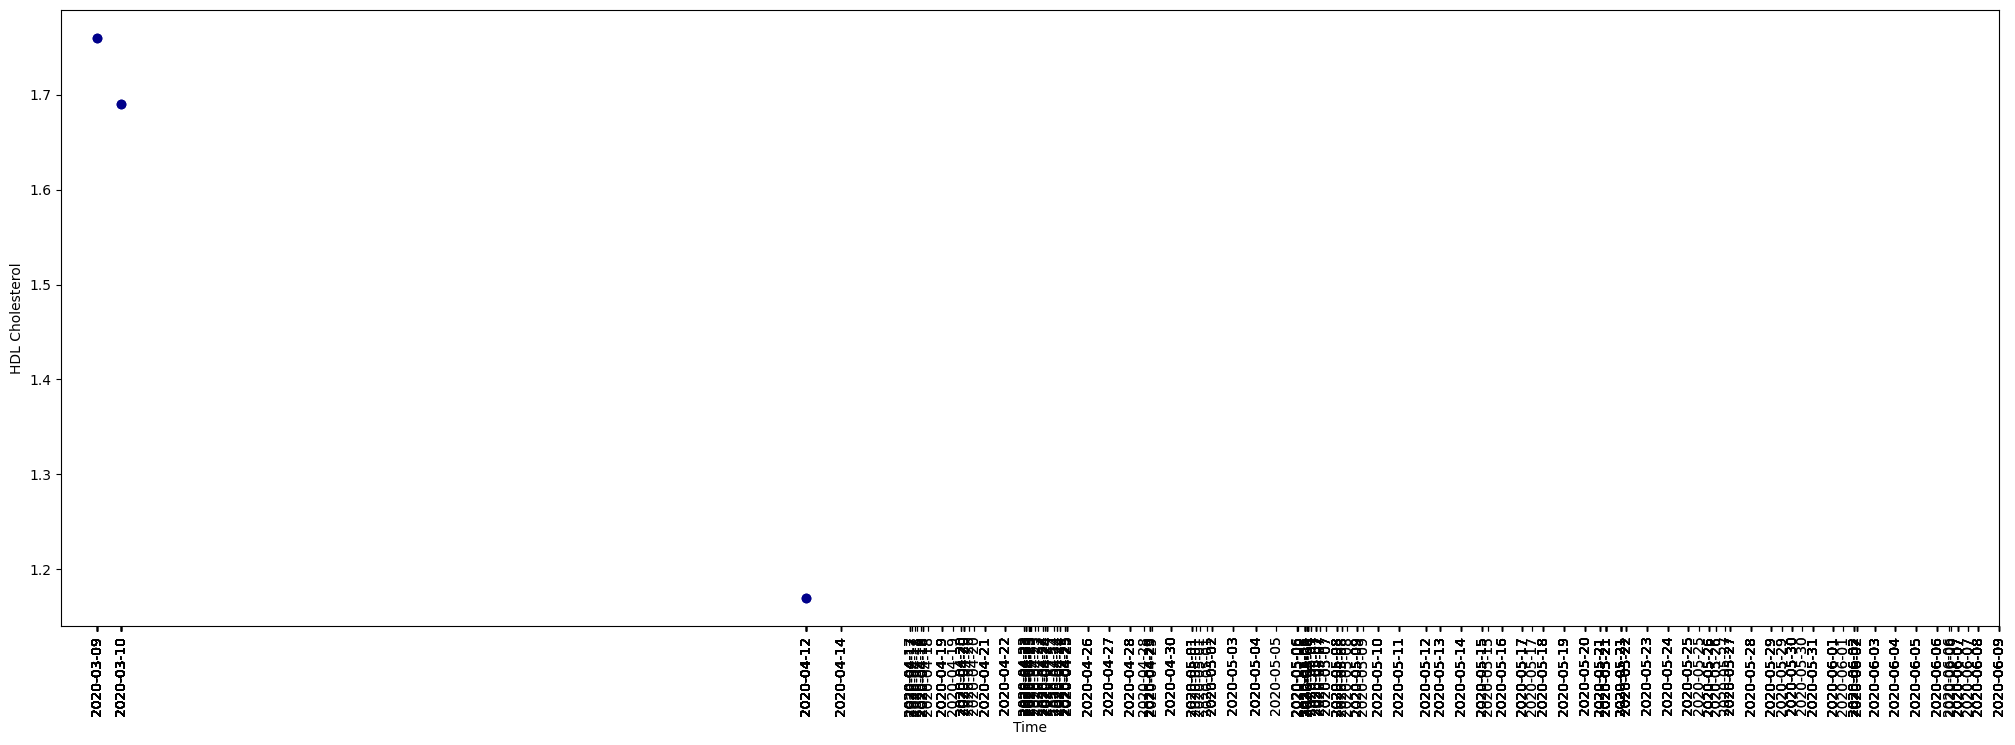

In [70]:

fig = plt.figure(figsize=[25,8])
ax = fig.subplots()
patient = 1139
c = np.random.choice(['CRP', 'Cholesterol', 'HDL Cholesterol', 'HbA1c',
                      'Hemoglobine', 'Kalium', 'Kreatinine', 'LDL Cholesterol', 'Natrium',
                      'Triglyceriden', 'eGFR (CKD-EPI)', 'non-HDL cholesterol'])
ax.plot(df_lab_timeseries.iloc[patient]['effectiveDateTime'],
                   df_lab_timeseries.iloc[patient][c],
                   'o',
                   c = 'DarkBlue',
                )
ax.set_xticks(df_lab_timeseries.loc[patient]['effectiveDateTime'])
ax.tick_params(axis='x', rotation=90)
ax.set_xlabel('Time')
ax.set_ylabel(f'{c}')

---

Impute values based on some nice MICE Forest algorithm:
- Pivoted on <code>code_display_original</code>
- Run MICE Forest

In [ ]:
ker = mf.ImputationKernel(
    df_lab_pivoted.reset_index(drop=True),
    num_datasets=2,
    save_all_iterations_data=True,
    random_state=42)

ker.mice(iterations = 5,
         n_estimators = 100,
         boosting = 'gbdt',
         min_sum_hessian_in_leaf = 0.01)


In [ ]:

df_lab_imputed = ker.complete_data()


In [ ]:
df_lab_imputed['studyId_0831'] = subjs

In [ ]:
df_lab_imputed.Kreatinine.plot()

In [ ]:
sns.heatmap(df_lab_imputed.isna())

In [ ]:
#ker.plot_imputed_distributions()

Try to aggregate values with using mean

In [ ]:
def wavg_last_n(x : pd.Series):
    weights = np.arange(start=1,stop=x.count()+1)/x.count()
    return np.average(x,weights=weights)

In [ ]:
df_lab_imputed.reset_index(drop=True)\
                .groupby('studyId_0831')\
                    .agg(lambda x: wavg_last_n(x))

In [ ]:
df_lab_imputed['CRP'].plot(kind='box')

In [ ]:
df_lab_imputed.reset_index(drop=True)\
        .groupby('studyId_0831')\
            .agg(lambda x: wavg_last_n(x))\
                .to_csv(r'C:\Users\jvitale\Desktop\Odin\ODIN\sandboxes\02_lab_meas\lab_meas_imputed.csv')